# Portfolio Opdracht 3: 


# 1. Inleiding
Je bent aangenomen als junior AI engineer bij VisionWear AI, een technologiebedrijf dat
kunstmatige intelligentie ontwikkelt voor de mode-industrie. Het bedrijf werkt samen met
webshops, modehuizen en online kledingplatforms om slimme AI-systemen te bouwen die
kleding automatisch kunnen herkennen, beschrijven en zelfs nieuwe ontwerpen kunnen
genereren.
VisionWear AI wil een volledig intelligent modesysteem ontwikkelen dat:
1. kledingstukken automatisch kan detecteren in afbeeldingen,
2. modieuze productbeschrijvingen kan schrijven,
3. en nieuwe kledingafbeeldingen kan genereren op basis van tekstuele beschrijvingen.
Om dit systeem te ontwikkelen heeft het bedrijf een grote dataset verzameld met
modefoto’s, labels en beschrijvingen. Jullie taak is om als data science-team verschillende AI-
modellen te bouwen die bijdragen aan deze innovatieve modepipeline.
De opdracht bestaat uit drie delen:
In deel 1 train je een model om kledingstukken en modeaccessoires in afbeeldingen te
identificeren. Jouw model moet de categorie van de artikel(en) voorspellen, evenals de
coördinaten van de locatie ervan binnen de afbeelding. Voor elke afbeelding kunnen een of
1
meer relevante items worden geïdentificeerd en hun locatie binnen de afbeelding kan
worden bepaald. Je neemt met een team deel aan een Kaggle-wedstrijd waarbij je het
opneemt tegen andere teams uit de opleiding Applied Data Science & AI. De team(s) die het
hoogst eindigt in de wedstrijd krijgt 5 bonuspunten bovenop het aantal behaalde punten
met de opdracht.
In deel 2 train je een model om tekstbijschriften (in het Engels) te genereren die de
kledingstukken beschrijven met behulp van relevante modetermen.
In deel 3 ga je een model fine-tunen om afbeeldingen van kleding te genereren op basis van
tekstbeschrijvingen (in het Engels

# Opdracht 2: Objectdetectie
 In deze deelopdracht werk je uitsluitend met de images en labels uit de data voor
deel 1. Bouw en train een objectdetectie model om de tien klassen kleding en
modeaccessoires in de dataset te detecteren en hun locaties te voorspellen met
behulp van bounding-boxes.

 Beschrijf in je eigen woorden hoe je model voorspellingen doet.

 Beschrijf hoe je de afbeeldingen voorbewerkt.

 Beschrijf in detail welke stappen, indien aanwezig, je onderneemt voor feature
engineering.

 Onderbouw je keuzes van de hyperparameters, de keuze van de optimizer en het
aantal trainingsepochs.

 Beschrijf de lossfunctie voor dit model in je eigen woorden en hoe deze werk

# Setup en Data Inladen

In [1]:
import os

# Omdat de cuda net geupdate is, werd alles opeens instabiel,
# en aangezien tensorflow en pytorch een hekel aan elkaar hebben, 
# moest ik deze workaround gebruiken,
# en gwn memory reserven voor beide frameworks
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Dank aan deze stackoverflow post die uitlegde ik fatsoenlijk mn cuda libraries moest linken,
# BRON: https://stackoverflow.com/questions/13428910/how-to-set-the-environment-variable-ld-library-path-in-linux 
os.environ['LD_LIBRARY_PATH'] = '/usr/lib:/opt/cuda/targets/x86_64-linux/lib'

import nlpaug.augmenter.word as naw
import spacy

# Memory limit fix voor tensorflow, zodat er genoeg VRAM overblijft voor pytorch
# Dankjewel aan Slingacademy voor deze uitleg en fix, 
# want zonder deze fix was het onmogelijk om beide frameworks te gebruiken op dezelfde GPU
# Omdat Tensforflow en Pytorch zo hungry is voor VRAM
# BRON: https://www.slingacademy.com/article/optimizing-memory-allocation-with-tensorflow-config/#preallocating-gpu-memory 
tensorflow_vram_limit = 130000
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:

        tf.config.set_logical_device_configuration(
            gpus[0], [tf.config.LogicalDeviceConfiguration(memory_limit=tensorflow_vram_limit)]
        )
        print(f"TensorFlow beperkt tot {tensorflow_vram_limit}")
    except: pass

import torch
from transformers import (
    pipeline, 
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    Trainer, 
    TrainingArguments, 
    AutoConfig,
    DataCollatorWithPadding,
    AutoModelForMaskedLM
)

print(f"Kan Pytorch bij de rest van de 12GB VRAM: {torch.cuda.is_available()}")

I0000 00:00:1779722717.692719   30843 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779722718.606030   30843 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow beperkt tot 130000
Kan Pytorch bij de rest van de 12GB VRAM: True


In [2]:
# Inladen van libraries
# iets in de volgorde zorgt ervoor dat er geen problemen zijn met cuda libraries,
# dus laat de volgorde zo staan AUB.
import os
import re
import gc
import random
import time
from pathlib import Path
from collections import Counter
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import IPython.display as ipd
import numpy as np
import pandas as pd

from scipy.sparse import csr_matrix, hstack

from tqdm.auto import tqdm

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler
from sklearn.utils import class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion

from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import plot_model

from datasets import Dataset

from torchview import draw_graph 

In [3]:

# En stellen hier een random state variable in, hierdoor blijven onze splits, 
# maar ook de modellering die daarbij komt kijken consistent met een set seed.
def set_seeds(seed=65):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    # Voor volledige GPU determinisme (waarschuwing: kan training vertragen)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_seeds(65)

RANDOM_STATE = 42

pd.set_option('display.max_columns', None)

In [4]:
BASE_DIR = Path.cwd()

TRAIN_DIR = BASE_DIR / "Train"
TEST_DIR = BASE_DIR / "Test"


train_images_dir = TRAIN_DIR / "images"
train_labels_dir = TRAIN_DIR / "labels"

test_images_dir = TEST_DIR / "images"

parsed_data = []


for img_path in train_images_dir.glob("*"):
    if img_path.suffix.lower() not in [".jpg"]:
        continue


    label_path = train_labels_dir / f"{img_path.stem}.txt"

    if label_path.exists():
        with open(label_path, "r", encoding="utf-8") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            if len(parts) == 5:
                parsed_data.append(
                    {
                        "image_path": str(img_path),
                        "label_path": str(label_path),
                        "image_name": img_path.name,
                        "class_id": int(parts[0]),
                        "center_x": float(parts[1]),
                        "center_y": float(parts[2]),
                        "width": float(parts[3]),
                        "height": float(parts[4]),
                    }
                )
    else:
        parsed_data.append(
            {
                "image_path": str(img_path),
                "label_path": None,
                "image_name": img_path.name,
                "class_id": None,
                "center_x": None,
                "center_y": None,
                "width": None,
                "height": None,
            }
        )

# Maak het DataFrame aan
train_df = pd.DataFrame(parsed_data)



In [5]:
print(f"Dimensies van het DataFrame: {train_df.shape}")

train_df.head()

Dimensies van het DataFrame: (8298, 8)


,image_path,label_path,image_name,class_id,center_x,center_y,width,height
0,/home/beef/Downloads/karaoke-k-klassificatie-2...,/home/beef/Downloads/karaoke-k-klassificatie-2...,1.jpg,8,0.68875,0.639167,0.3025,0.118333
1,/home/beef/Downloads/karaoke-k-klassificatie-2...,/home/beef/Downloads/karaoke-k-klassificatie-2...,1.jpg,7,0.65000,0.429167,0.4150,0.411667
2,/home/beef/Downloads/karaoke-k-klassificatie-2...,/home/beef/Downloads/karaoke-k-klassificatie-2...,1.jpg,9,0.61000,0.900833,0.1450,0.118333
3,/home/beef/Downloads/karaoke-k-klassificatie-2...,/home/beef/Downloads/karaoke-k-klassificatie-2...,100034.jpg,3,0.56875,0.257500,0.3275,0.175000
4,/home/beef/Downloads/karaoke-k-klassificatie-2...,/home/beef/Downloads/karaoke-k-klassificatie-2...,100034.jpg,8,0.70625,0.480833,0.2125,0.188333


In [6]:
def check_dataset(df, label):
    """
    Print informatie over het DataFrame en de bijbehorende Wav-bestanden,
    zoals het aantal records, ontbrekende waarden en het aantal Wav-bestanden in de directory.

    Args:
        df (pd.DataFrame): Het DataFrame met de kolom 

    Returns:
        Een overzicht van de dataset, inclusief het aantal records, ontbrekende waarden en het aantal Wav-bestanden.
    """

    display(df.head(1))
    print(f"{label.lower()}_df shape = {df.shape}")
    
    # We gebruiken rglob om recurively door de files te kijken
    # hierdoor hoeven we niet specifiek te kijken voor genre mappen
    # en meer robuust voor het geval een files is misplaced


    
    print("\nOntbrekende waarden in dataframe:")
    print(df.isna().sum())


In [ ]:
print("Aantal unieke afbeeldingen:", train_df["image_name"].nunique())
check_dataset(train_df, "Train")

,image_path,label_path,image_name,class_id,center_x,center_y,width,height
0,/home/beef/Downloads/karaoke-k-klassificatie-2...,/home/beef/Downloads/karaoke-k-klassificatie-2...,1.jpg,8,0.68875,0.639167,0.3025,0.118333


train_df shape = (8298, 8)

Ontbrekende waarden in dataframe:
image_path    0
label_path    0
image_name    0
class_id      0
center_x      0
center_y      0
width         0
height        0
dtype: int64


In [33]:
import cv2
import matplotlib.patches as patches

# 2. EDA

In [42]:
# Hier hebben we vaste kleuren ingesteld voor de genres, 
# zodat alles consistent blijft qua overzicht en graphics.
clothing_colors = {
    'sunglass': "#ff0000",  
    'hat': "#ff7b00",
    'jacket': "#a29a00", # keb geel donkerder gemaakt, anders was de witte txt niet te zien
    'shirt': "#b7ff00",  
    'pants': "#00FF6A",   
    'shorts': "#00ffe5",  
    'skirt': "#0000ff",     
    'dress': "#6f00ff",
    'bag': "#d400ff", 
    'shoe': "#ff0090"}

clothing_labels = {
    0: "sunglass",
    1: "hat",
    2: "jacket",
    3: "shirt",
    4: "pants",
    5: "shorts",
    6: "skirt",
    7: "dress",
    8: "bag",
    9: "shoe",
}

## 2.x. Clothing Class Aantallen

/tmp/ipykernel_30843/1596705717.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


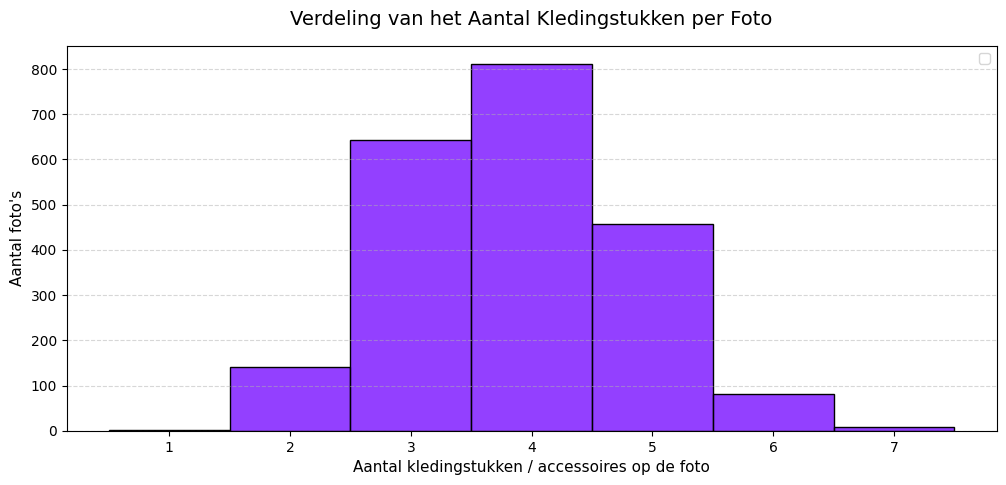

In [37]:
df_summary = train_df.groupby('image_name').agg(
    totaal_tags=('class_id', 'count')
).reset_index()


max_stukken = df_summary['totaal_tags'].max()
min_stukken = df_summary['totaal_tags'].min()



plt.figure(figsize=(12, 5))


sns.histplot(
    data=df_summary, 
    x='totaal_tags', 
    discrete=True, 
    kde=False, 
    color='#6f00ff', 
    alpha=0.75
)


plt.title('Verdeling van het Aantal Kledingstukken per Foto', fontsize=14, pad=15)
plt.xlabel('Aantal kledingstukken / accessoires op de foto', fontsize=11)
plt.ylabel('Aantal foto\'s', fontsize=11)
plt.xticks(range(int(min_stukken), int(max_stukken) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()

plt.show()

analyse

shoe        :  2081
shirt       :  1486
bag         :  1188
jacket      :   777
skirt       :   697
dress       :   550
pants       :   508
shorts      :   395
sunglass    :   343
hat         :   273


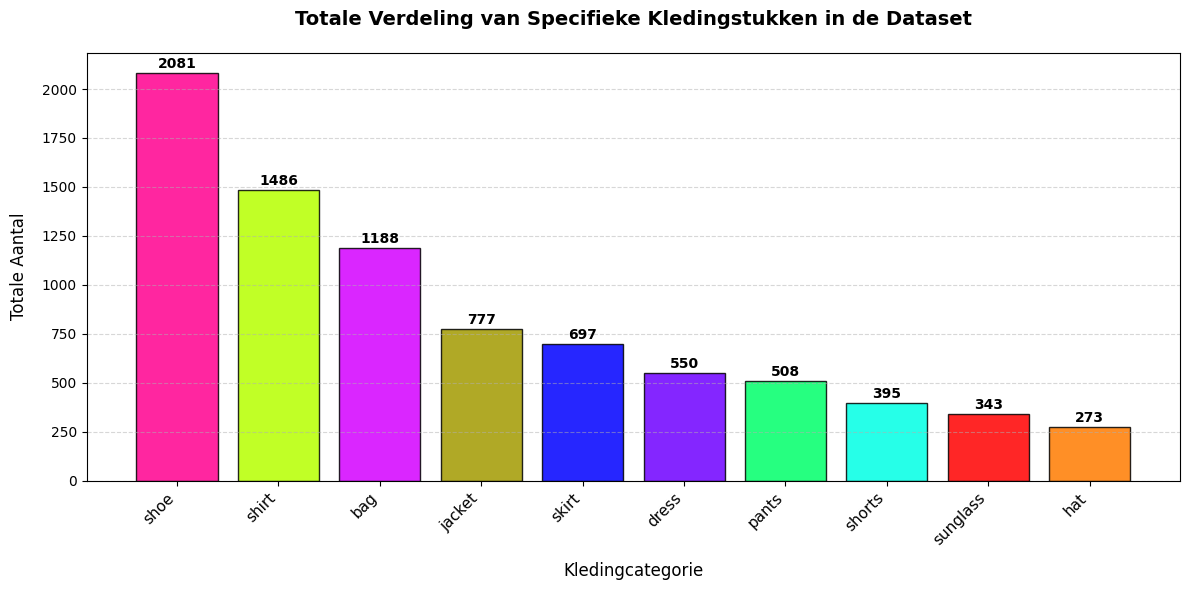

In [43]:
train_df['class_name'] = train_df['class_id'].map(clothing_labels)


counts = train_df['class_name'].value_counts()
percentages = train_df['class_name'].value_counts(normalize=True) * 100

for name in counts.index:
    print(f"{name.ljust(12)}: {str(counts[name]).rjust(5)}")


plot_colors = [clothing_colors.get(name, "#333333") for name in counts.index]

plt.figure(figsize=(12, 6))

bars = plt.bar(counts.index, counts.values, color=plot_colors, edgecolor='black', alpha=0.85)


for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + 10, 
        f'{int(yval)}', 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        weight='bold'
    )

plt.title('Totale Verdeling van Specifieke Kledingstukken in de Dataset', fontsize=14, pad=20, weight='bold')
plt.xlabel('Kledingcategorie', fontsize=12, labelpad=10)
plt.ylabel('Totale Aantal', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

analyse

## 2.x. Fotos

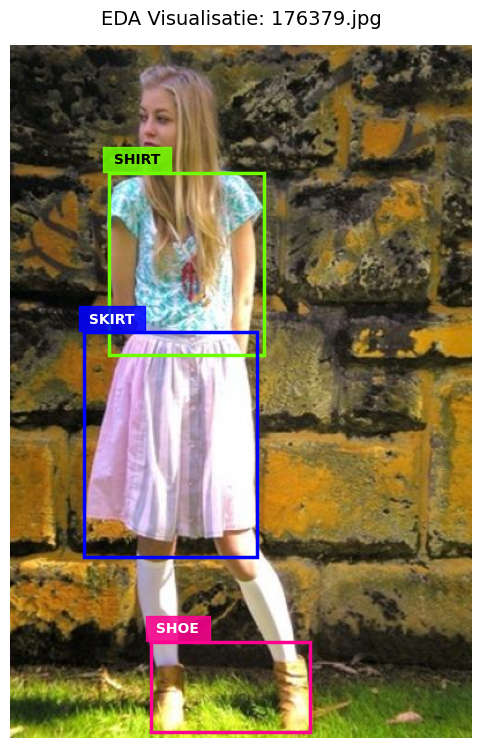

In [ ]:
train_df["class_name"] = train_df["class_id"].map(clothing_labels)


def plot_fashion_image(df, image_name=None):
    if image_name is None:
        image_name = np.random.choice(df["image_name"].unique())

    img_objects = df[df["image_name"] == image_name]

    img_path = img_objects.iloc[0]['image_path']
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_h, img_w, _ = image.shape

    fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(image)

    for _, row in img_objects.iterrows():
        c_name = row["class_name"]
        box_color = clothing_colors.get(c_name, "#FFFFFF")

        w = row["width"] * img_w
        h = row["height"] * img_h
        xmin = (row["center_x"] - row["width"] / 2) * img_w
        ymin = (row["center_y"] - row["height"] / 2) * img_h

        rect = patches.Rectangle(
            (xmin, ymin),
            w,
            h,

            linewidth=2.5,
            edgecolor=box_color,
            facecolor="none",
        )
        ax.add_patch(rect)

        text_color = "black" if c_name in ["shirt", "shorts"] else "white"

        ax.text(
            xmin,
            ymin - 8,
            f" {c_name.upper()} ",
            color=text_color,
            fontsize=10,
            weight="bold",
            bbox=dict(facecolor=box_color, edgecolor=box_color, alpha=0.85),
        )

    plt.title(f"EDA Visualisatie: {image_name}", fontsize=14, pad=15)
    plt.axis("off")
    plt.show()


plot_fashion_image(train_df)

analyse

# Opdracht 4: Beeldgeneratie
 In deze deelopdracht werk je met de H&M images en captions dataset.

 Voor deze opdracht kies je een voorgetraind model van Hugging Face en fine-tune dit
op de afbeeldingen en tekstdataset.

 Geef de naam op van de modelarchitectuur die je hebt gekozen en de dataset
waarop deze vooraf is getraind.

 Je model moet een Engels tekstbijschrift als input gebruiken en een afbeelding als
output maken.

 Beschrijf in detail de stappen die worden genomen bij het finetunen van dit vooraf
getraind model.

 Beschrijf de componenten van dit model.

 Beschrijf in je eigen woorden hoe het model afbeeldingen maakt en welke lossfunctie
het gebruikt.

 Onderbouw je keuzes van de hyperparameters, de keuze van de optimizer en het
aantal trainingsepoch

# Opdracht 5: Implementatie

 Maak een eenvoudige app die een foto als input gebruikt, kledingstukken en
modeaccessoires detecteert en hun locatie geeft, en tekstbeschrijvingen genereert
van elk kledingstuk in de afbeelding. Gebruik de modellen die je in de voorgaande
opdrachten hebt getraind/gefinetuned.

 De app gebruikt een foto als input en voorspelt de locatie van elk afzonderlijk
kledingstuk en modeaccessoire. Vervolgens worden de individuele
kledingstukken/mode-items voorzien van bijschriften. De bijschriften moeten voor
elk afzonderlijk gedetecteerd item afzonderlijk worden gegenereerd.

 Let op: Je hoeft deze app niet te deployen. Je hoeft alleen maar de modellen in jouw
notebook uit te voeren en de voorspellingen op de juiste manier te combineren.

 Geef een samenvatting van de uitkomsten van het modelleren.
o Geef een beknopt overzicht van de resultaten.

o (Voor deel 1) Toon je scores op Kaggle en laat zien wat de resultaten waren
van je verbeteringen op je score op Kaggle.

o (Voor deel 2 & 3) Geef voorbeelden van je getrainde modellen in actie en
evalueer hun prestaties.

o Geef een voorbeeld/voorbeelden van hoe je app kleding en modeaccessoires
detecteert en geschikte bijschriften genereert voor elk gedetecteerd ite

# Opdracht 6: Conclusie en aanbevelingen
 Beschrijf het modelleringsproces voor deze opdracht. Wat waren de uitdagingen
daarmee?

 Wat zou je aanbevolen gebruik zijn van de modellen die je hebt getraind?

 Wat zouden je aanbevelingen zijn met betrekking tot het soort afbeeldingen/data
waarop je deze modellen kunt gebruiken?

 Zijn de resultaten van je modellen accuraat/betrouwbaar? Wat kan er gedaan
worden om deze te verbeteren?